# Figure 2 - Brownian Motion vs Gradient Descent

This notebook reproduces the Section 4.2 case study on the true-label MNIST classification MDP.  The reusable MLP and true-label MDP live in `src.models.mlp` and `configs.environments.easy_mdp`; this notebook keeps the run broken into inspectable steps.

In [1]:
import argparse
import copy
import math
import random
from collections import deque
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Deque, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from torchvision import datasets, transforms
from tqdm import tqdm

from src.environments.easy_mdp import EasyMDP
from src.models.mlp import MLP
from src.agents.replay_buffer import ReplayBuffer

from src.pyhessian import Hessian

In [2]:
seed: int = 42
data_root: str = "./data"
download: bool = False
hidden_dim: int = 512
gamma: float = 0.99
lr: float = 1e-3
batch_size: int = 512
replay_capacity: int = 10_000
prefill_steps: int = 5_000
train_steps: int = 200_000
target_update_period: int = 5_000
epsilon: float = 0.1
probe_batch_size: int = 512
cov_batch_size: int = 512
esd_points: int = 600

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
class QNetwork(MLP):
    def __init__(self, hidden_dim: int = 512):
        super().__init__(input_shape=(1, 28, 28), num_actions=10, hidden_dim=hidden_dim)

In [6]:
# load the data and create the environment
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=download,
    transform=transform,
)

## Sanity Check the Shared Components

Before running the long loop, instantiate the shared MLP and true-label MDP, then step the environment once.

In [7]:
env = EasyMDP(dataset, seed=seed)

In [8]:
replay = ReplayBuffer(capacity=replay_capacity)


@torch.no_grad()
def select_action(model: QNetwork, obs: torch.Tensor, epsilon: float) -> int:
    if random.random() < epsilon:
        return random.randrange(10)

    q_values = model(obs.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(
    env: EasyMDP,
    model: QNetwork,
    replay: ReplayBuffer,
    epsilon: float,
) -> None:
    state = int(env.state)
    obs = env.sample_observation(state)
    action = select_action(model, obs, epsilon)
    next_obs, reward, next_state = env.step(action)
    replay.push(obs.cpu(), action, reward, next_obs.cpu())

## Run the Experiment

The run couples two trajectories from the same initialization: one follows SGD on the Q-learning objective, and the other receives Brownian parameter perturbations with the same update norm.

In [9]:
gd_model = QNetwork(hidden_dim).to(device)
bm_model = QNetwork(hidden_dim).to(device)
target_model = copy.deepcopy(gd_model).to(device)

In [10]:
optimizer = torch.optim.SGD(gd_model.parameters(), lr=lr)

In [11]:
def q_learning_loss(
    model: QNetwork,
    target_model: QNetwork,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
) -> torch.Tensor:
    states, actions, rewards, next_states = batch
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)

    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        td_target = rewards + gamma * next_q

    return F.mse_loss(q_sa, td_target)

In [12]:
def sgd_step_and_update_norm(
    model: QNetwork,
    target_model: QNetwork,
    optimizer: torch.optim.Optimizer,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
    lr: float,
) -> Tuple[float, float]:
    model.train()
    loss = q_learning_loss(model, target_model, batch, gamma)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    update_norm_sq = torch.zeros((), device=device)
    for p in model.parameters():
        if p.grad is not None:
            update_norm_sq += (lr * p.grad).pow(2).sum()

    optimizer.step()
    return float(loss.detach().cpu().item()), float(update_norm_sq.sqrt().cpu().item())


@torch.no_grad()
def brownian_step(model: QNetwork, step_norm: float) -> None:
    if step_norm <= 0:
        return

    noise = [torch.randn_like(p) for p in model.parameters()]
    total_norm = torch.sqrt(sum((n * n).sum() for n in noise))
    scale = step_norm / (float(total_norm.item()) + 1e-12)

    for p, n in zip(model.parameters(), noise):
        p.add_(n * scale)

In [13]:
@torch.no_grad()
def evaluate_policy(
    model: QNetwork,
    env: EasyMDP,
    num_samples: int = 2048,
) -> float:
    model.eval()
    correct = 0

    for _ in range(num_samples):
        state = random.randrange(10)
        obs = env.sample_observation(state)
        pred = model(obs.unsqueeze(0).to(device)).argmax(dim=1).item()
        correct += int(pred == state)

    return correct / float(num_samples)

In [14]:
# prefill the replay buffer
print("Prefilling replay buffer...")
for _ in tqdm(range(prefill_steps)):
    collect_transition(env, gd_model, replay, epsilon)

Prefilling replay buffer...


100%|██████████| 5000/5000 [00:00<00:00, 10161.69it/s]


In [15]:
replay.sample(batch_size)[2]

tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 

In [16]:
for step in tqdm(range(1, train_steps + 1)):

    collect_transition(env, gd_model, replay, epsilon=epsilon)

    batch = replay.sample(batch_size)
    loss, update_norm = sgd_step_and_update_norm(
        gd_model,
        target_model,
        optimizer,
        batch,
        gamma,
        lr,
    )
    brownian_step(bm_model, update_norm)

    if step % target_update_period == 0:
        # save a snapshot of the current model parameters to the checkpoint directory
        torch.save(gd_model.state_dict(), f"./checkpoints/hessian_step_{step}.pt")
        target_model.load_state_dict(gd_model.state_dict())
        target_update = step // target_update_period
        accuracy = evaluate_policy(gd_model, env, num_samples=1024)
        log_row = {
            "step": float(step),
            "target_update": float(target_update),
            "loss": float(loss),
            "update_norm": float(update_norm),
            "accuracy": float(accuracy),
        }
        print(
            "target update "
            f"{int(log_row['target_update'])}: "
            f"step={step}, loss={loss:.4f}, "
            f"update_norm={update_norm:.5f}, accuracy={accuracy:.3f}"
        )

  3%|▎         | 5008/200000 [01:23<56:23, 57.62it/s]  

target update 1: step=5000, loss=0.0878, update_norm=0.00017, accuracy=0.312


  5%|▌         | 10007/200000 [02:44<58:16, 54.33it/s]  

target update 2: step=10000, loss=0.1124, update_norm=0.00012, accuracy=0.398


  8%|▊         | 15007/200000 [04:04<57:54, 53.25it/s]  

...

target update 38: step=190000, loss=0.0755, update_norm=0.00107, accuracy=0.922


 98%|█████████▊| 195012/200000 [56:32<01:22, 60.31it/s]

target update 39: step=195000, loss=0.0971, update_norm=0.00907, accuracy=0.934


100%|██████████| 200000/200000 [57:54<00:00, 57.56it/s]

target update 40: step=200000, loss=0.0693, update_norm=0.00218, accuracy=0.932


In [22]:
# get a batch to calculate the Hessian and ESD
probe_batch = replay.sample(1024)

def make_probe_targets(
    model: QNetwork,
    inputs: torch.Tensor,
    noise: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        if noise is None:
            noise = torch.randn_like(outputs)
        return (outputs + noise).detach(), noise.detach()

In [23]:
probe_targets, _ = make_probe_targets(gd_model, probe_batch[0])
hessian = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets),
    criterion=F.mse_loss,
    cuda=False,
)

In [24]:
eig, weight = hessian.density(iter=100, n_v=3)

In [36]:

def gaussian(x, x0, sigma_squared):
    return np.exp(-(x0 - x)**2 /
                  (2.0 * sigma_squared)) / np.sqrt(2 * np.pi * sigma_squared)

def density_generate(eigenvalues,
                     weights,
                     num_bins=10000,
                     sigma_squared=1e-5,
                     overhead=0.01):

    eigenvalues = np.real(np.asarray(eigenvalues))
    weights = np.real(np.asarray(weights))

    lambda_max = np.mean(np.max(eigenvalues, axis=1), axis=0) + overhead
    lambda_min = np.mean(np.min(eigenvalues, axis=1), axis=0) - overhead

    grids = np.linspace(lambda_min, lambda_max, num=num_bins)
    sigma = sigma_squared * max(1, (lambda_max - lambda_min))

    num_runs = eigenvalues.shape[0]
    density_output = np.zeros((num_runs, num_bins))

    for i in range(num_runs):
        for j in range(num_bins):
            x = grids[j]
            tmp_result = gaussian(eigenvalues[i, :], x, sigma)
            density_output[i, j] = np.sum(tmp_result * weights[i, :])
    density = np.mean(density_output, axis=0)
    normalization = np.sum(density) * (grids[1] - grids[0])
    density = density / normalization
    return density, grids


def get_esd_plot(eigenvalues, weights):
    eigenvalues = np.real(np.asarray(eigenvalues))
    density, grids = density_generate(eigenvalues, weights)
    plt.plot(grids, density)
    plt.ylabel('Density', fontsize=14, labelpad=10)
    plt.xlabel('Eigenvalue', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.axis([eigenvalues.min() - 1, eigenvalues.max() + 1, None, None])
    plt.tight_layout()
    plt.savefig('example.pdf')


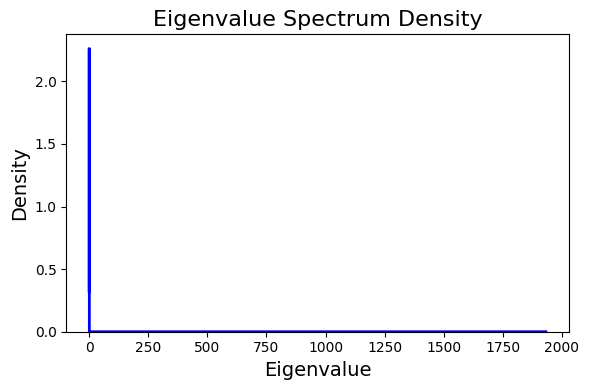

In [37]:
# plotting the smoothed eigenvalue spectrum density
density, grids = density_generate(eig, weight)

plt.figure(figsize=(6, 4))
plt.title("Eigenvalue Spectrum Density", fontsize=16)
plt.xlabel("Eigenvalue", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.plot(grids, density, color="blue", lw=2)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig('example.pdf')